# Binary Classification with Keras

This notebook demonstrates a binary classification problem using Keras, including training, evaluation, visualization, and prediction.

## 1. Import Libraries

In [2]:
%pip install tensorflow

  Using cached tensorflow-2.20.0-cp312-cp312-win_amd64.whl.metadata (4.6 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached grpcio-1.76.0-cp312-cp312-win_amd64.whl.metadata (3.8 kB)
  Using cached tensorboard-2.20.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached h5py-3.15.1-cp312-cp312-win_amd64.whl.metadata (3.1 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached tensorboard_data_server-0.7.2-py3-none-any.whl.metadata (1.1 kB)
  Using cached markupsafe-3.0.3-cp312-cp312-win_amd64.whl.metadata (2.8 kB)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
Usin


[notice] A new release of pip is available: 25.0.1 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

I0000 00:00:1778209320.569802   34195 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778209321.221230   34195 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778209323.335425   34195 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 2. Generate a Binary Classification Dataset

In [2]:
# Sinh dữ liệu phân loại nhị phân ngẫu nhiên
X, y = make_classification(
    n_samples=1000,        # Số mẫu dữ liệu
    n_features=2,          # Số đặc trưng đầu vào
    n_informative=2,       # Số đặc trưng có ý nghĩa
    n_redundant=0,
    n_classes=2,
    random_state=42
)

## 3. Train-Test Split

In [3]:
# Chia dữ liệu thành tập huấn luyện và tập kiểm tra
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 4. Build the Neural Network Model

In [4]:
# Khởi tạo mô hình mạng neural
model = Sequential()

# Tầng ẩn thứ nhất
model.add(Dense(16, activation='relu', input_shape=(2,)))

# Tầng ẩn thứ hai
model.add(Dense(8, activation='relu'))

# Tầng đầu ra cho phân loại nhị phân
model.add(Dense(1, activation='sigmoid'))

/home/zhu/micromamba/envs/tf/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
W0000 00:00:1778209382.363920   34195 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## 5. Compile the Model

In [5]:
# Biên dịch mô hình với Binary Cross-Entropy
model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## 6. Train the Model

In [6]:
# Huấn luyện mô hình
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8583 - loss: 0.3687 - val_accuracy: 0.7750 - val_loss: 0.5055
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8889 - loss: 0.2920 - val_accuracy: 0.7750 - val_loss: 0.4703
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8917 - loss: 0.2825 - val_accuracy: 0.7750 - val_loss: 0.4371
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8944 - loss: 0.2666 - val_accuracy: 0.7750 - val_loss: 0.4137
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9014 - loss: 0.2509 - val_accuracy: 0.8250 - val_loss: 0.3482
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8986 - loss: 0.2422 - val_accuracy: 0.8125 - val_loss: 0.3363
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9028 - loss: 0.2297 - val_accuracy: 0.8125 - val_loss: 0.3336
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9125 - loss: 0.2220 - val_accuracy: 0.8250 - val_loss

## 7. Plot Training Loss and Accuracy

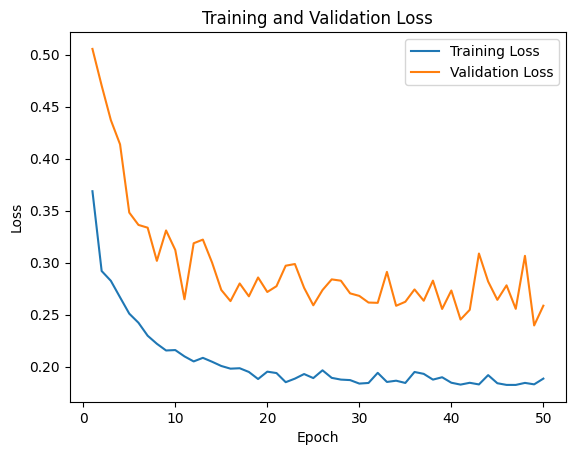

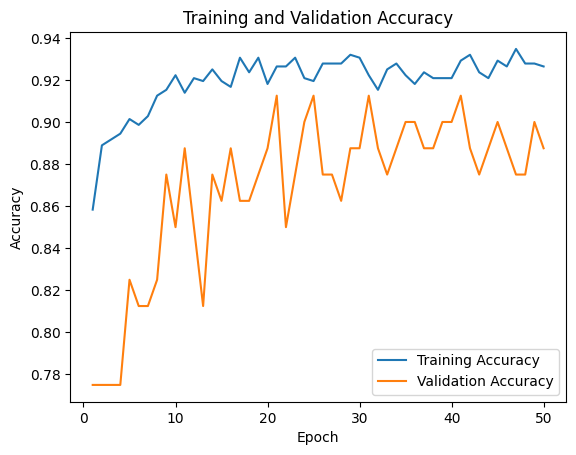

In [7]:
# Lấy dữ liệu loss và accuracy từ history
loss = history.history['loss']
val_loss = history.history['val_loss']
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

epochs = range(1, len(loss) + 1)

# Vẽ đồ thị Loss
plt.figure()
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# Vẽ đồ thị Accuracy
plt.figure()
plt.plot(epochs, accuracy, label='Training Accuracy')
plt.plot(epochs, val_accuracy, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

## 8. Evaluate the Model

In [8]:
# Đánh giá mô hình trên tập kiểm tra
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss: 0.1674
Test Accuracy: 0.9300


## 9. Confusion Matrix and Classification Report

In [9]:
# Dự đoán xác suất trên tập kiểm tra
y_pred_prob = model.predict(X_test)

# Chuyển xác suất sang nhãn nhị phân
y_pred = (y_pred_prob >= 0.5).astype(int)

# Tính confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# In classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Confusion Matrix:
[[93  8]
 [ 6 93]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93       101
           1       0.92      0.94      0.93        99

    accuracy                           0.93       200
   macro avg       0.93      0.93      0.93       200
weighted avg       0.93      0.93      0.93       200



## 10. Visualize Confusion Matrix

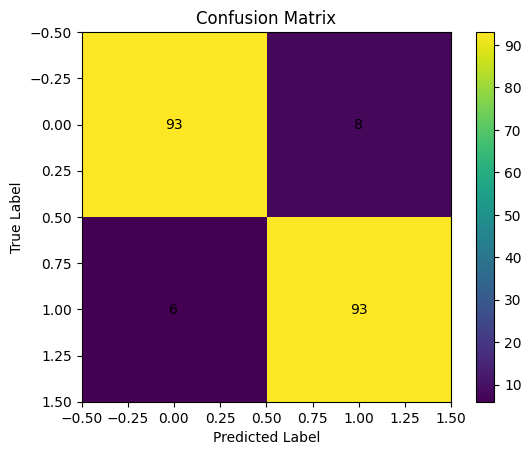

In [10]:
# Vẽ confusion matrix
plt.figure()
plt.imshow(cm)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

## 11. Predict on New Random Data

In [11]:
# Sinh dữ liệu mới ngẫu nhiên
new_data = np.random.randn(5, 2)

# Dự đoán xác suất
new_pred_prob = model.predict(new_data)

# Dự đoán nhãn
new_pred_label = (new_pred_prob >= 0.5).astype(int)

print('New data:')
print(new_data)

print('Predicted probabilities:')
print(new_pred_prob)

print('Predicted labels:')
print(new_pred_label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
New data:
[[-0.31002291  0.43886916]
 [-0.06729877 -0.80560189]
 [-1.82654755  0.6679653 ]
 [-0.33454742  0.9800697 ]
 [ 0.16715143 -0.25924197]]
Predicted probabilities:
[[0.8281398 ]
 [0.2779337 ]
 [1.        ]
 [0.60229576]
 [0.7394067 ]]
Predicted labels:
[[1]
 [0]
 [1]
 [1]
 [1]]
